# SnapBoost Regression Example

This notebook demonstrates continuous target prediction with **SnapBoost** on the [Diabetes](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html) dataset.

In regression mode, SnapBoost minimizes mean squared error using the same heterogeneous learner pool. We also compare results against **XGBoost** and **LightGBM**, two tree-only gradient boosting baselines.

> **Note:** XGBoost and LightGBM are optional notebook dependencies: `pip install xgboost lightgbm`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from snapboost import SnapBoostRegressor

## Load and split the data

In [2]:
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
feature_names = diabetes.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"Features:         {', '.join(feature_names)}")
print(f"Target range:     [{y.min():.1f}, {y.max():.1f}]")

Training samples: 331
Test samples:     111
Features:         age, sex, bmi, bp, s1, s2, s3, s4, s5, s6
Target range:     [25.0, 346.0]


## Train SnapBoost

In [3]:
model = SnapBoostRegressor(
    num_iterations=100,
    learning_rate=0.1,
    random_state=42,
    verbose=True,
)

model.fit(X_train, y_train)


Training:   0%|                                                                                                           | 0/100 [00:00<?, ?it/s]


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 1124.84it/s]

,num_iterations,100
,learning_rate,0.1
,p_tree,0.9
,min_max_depth,2
,max_max_depth,4
,min_samples_leaf,10
,alpha,1.0
,gamma,1.0
,n_components,100
,random_state,42
,verbose,True


## Evaluate on the test set

In [4]:
r2 = model.score(X_test, y_test)
print(f"R²: {r2:.4f}")

rmse = model.evaluate(X_test, y_test)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.4f}")

R²: 0.4389
RMSE: 55.7011
MAE: 44.1730


## Compare with XGBoost and LightGBM

All three models use 100 boosting rounds and learning rate 0.1. XGBoost and LightGBM use `max_depth=6`. SnapBoost samples tree depths from `[2, 4]` with `min_samples_leaf=10` for regularization, and mixes in an RFF ridge learner with `p_tree=0.9`.

In [5]:
N_ESTIMATORS = 100
LEARNING_RATE = 0.1
RANDOM_STATE = 42
MAX_DEPTH = 6

boosting_params = dict(
    n_estimators=N_ESTIMATORS,
    learning_rate=LEARNING_RATE,
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE,
)

models = {
    "SnapBoost": model,
    "XGBoost": XGBRegressor(**boosting_params, verbosity=0),
    "LightGBM": LGBMRegressor(**boosting_params, verbosity=-1),
}

comparison = []
for name, fitted_model in models.items():
    if name != "SnapBoost":
        fitted_model.fit(X_train, y_train)
    r2 = fitted_model.score(X_test, y_test)
    y_pred = fitted_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    comparison.append({"Model": name, "R²": r2, "RMSE": rmse, "MAE": mae})

comparison_df = pd.DataFrame(comparison).set_index("Model")
comparison_df

/home/samson/miniconda3/envs/qiancapital-dev/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/samson/miniconda3/envs/qiancapital-dev/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,R²,RMSE,MAE
Model,,,
SnapBoost,0.438917,55.701140,44.172995
XGBoost,0.382513,58.433840,47.757611
LightGBM,0.398492,57.672784,44.761941


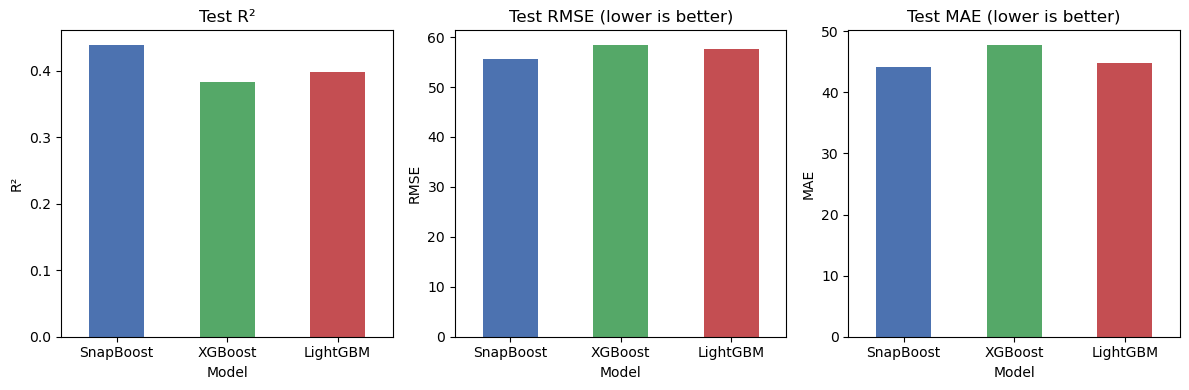

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ["#4C72B0", "#55A868", "#C44E52"]

comparison_df["R²"].plot.bar(ax=axes[0], color=colors)
axes[0].set_ylabel("R²")
axes[0].set_title("Test R²")
axes[0].tick_params(axis="x", rotation=0)

comparison_df["RMSE"].plot.bar(ax=axes[1], color=colors)
axes[1].set_ylabel("RMSE")
axes[1].set_title("Test RMSE (lower is better)")
axes[1].tick_params(axis="x", rotation=0)

comparison_df["MAE"].plot.bar(ax=axes[2], color=colors)
axes[2].set_ylabel("MAE")
axes[2].set_title("Test MAE (lower is better)")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Predicted vs. actual

This chart compares test-set targets to model outputs:

- **Blue dots** — one point per test sample (`x` = actual, `y` = predicted)
- **Red dashed line** — perfect predictions (`predicted == actual`), **not** the model fit

There is no separate "model line" here: regression quality is read from how closely the dots hug the diagonal. Points far above or below the line are over- or under-predictions.

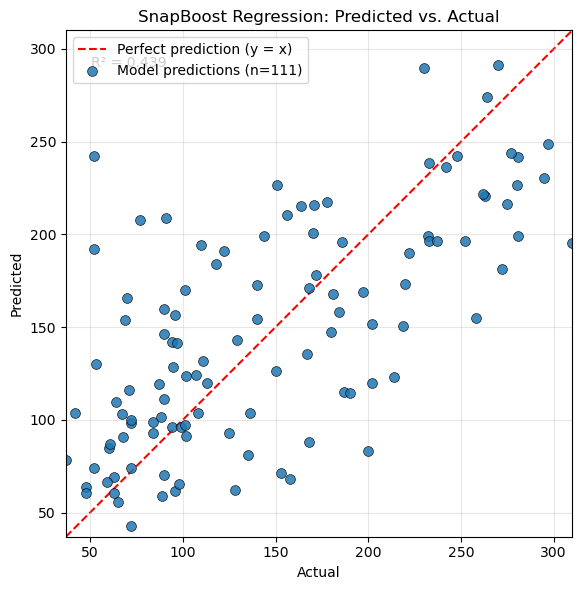

In [7]:
y_pred = model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max()),
]

# Reference line first so points render on top.
ax.plot(
    lims,
    lims,
    "r--",
    linewidth=1.5,
    label="Perfect prediction (y = x)",
    zorder=1,
)
ax.scatter(
    y_test,
    y_pred,
    s=50,
    alpha=0.85,
    c="tab:blue",
    edgecolors="black",
    linewidths=0.5,
    label=f"Model predictions (n={len(y_test)})",
    zorder=2,
)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title("SnapBoost Regression: Predicted vs. Actual")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_aspect("equal", adjustable="box")

r2 = model.score(X_test, y_test)
ax.text(0.05, 0.95, f"R² = {r2:.3f}", transform=ax.transAxes, va="top")

plt.tight_layout()
plt.show()

## Feature vs. target with model fit

The diabetes dataset has 10 input features, so there is no single straight "regression line" through a 2-D scatter. To visualize how the model behaves, we plot **BMI** (the feature most correlated with the target) against actual disease progression on the test set, then overlay SnapBoost's **fitted curve** when all other features are held at their training-set medians.

- **Blue dots** — actual test outcomes
- **Red line** — model predictions as BMI varies (partial dependence slice)

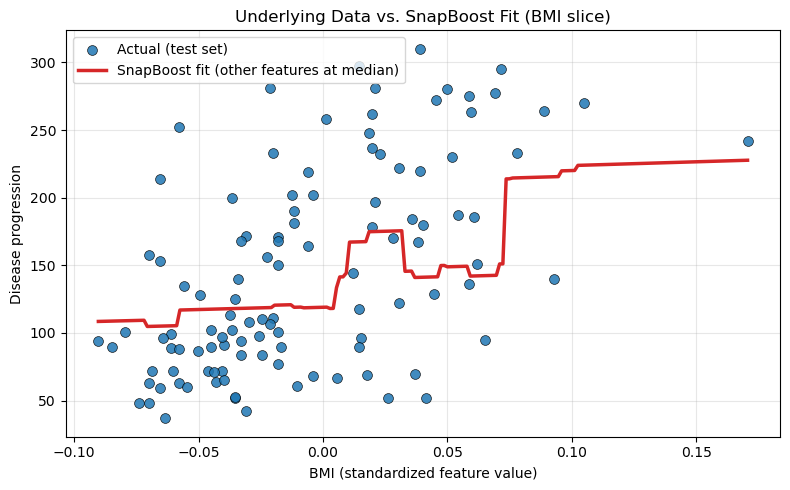

In [8]:
bmi_idx = list(feature_names).index("bmi")
x_test_bmi = X_test[:, bmi_idx]

# Hold non-BMI features at training medians, sweep BMI across its observed range.
medians = np.median(X_train, axis=0)
bmi_grid = np.linspace(X[:, bmi_idx].min(), X[:, bmi_idx].max(), 200)
X_slice = np.tile(medians, (len(bmi_grid), 1))
X_slice[:, bmi_idx] = bmi_grid
y_fit = model.predict(X_slice)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    x_test_bmi,
    y_test,
    s=50,
    alpha=0.85,
    c="tab:blue",
    edgecolors="black",
    linewidths=0.5,
    label="Actual (test set)",
    zorder=2,
)
ax.plot(
    bmi_grid,
    y_fit,
    color="tab:red",
    linewidth=2.5,
    label="SnapBoost fit (other features at median)",
    zorder=3,
)

ax.set_xlabel("BMI (standardized feature value)")
ax.set_ylabel("Disease progression")
ax.set_title("Underlying Data vs. SnapBoost Fit (BMI slice)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Residual distribution

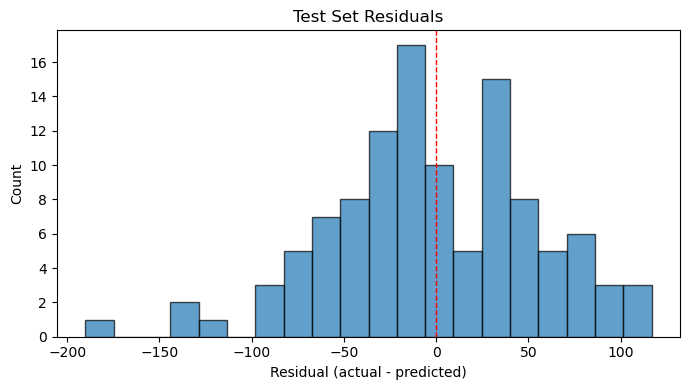

In [9]:
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(residuals, bins=20, edgecolor="black", alpha=0.7)
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Residual (actual - predicted)")
ax.set_ylabel("Count")
ax.set_title("Test Set Residuals")
plt.tight_layout()
plt.show()